# 02 — Lei de Benford: valores de licitações (jan/2024)

Teste de conformidade dos primeiros dígitos com a distribuição de Benford,
usando o módulo `src/benford.py`.

## Resultado
- Aderência visual quase perfeita (dígito 1: 30,3% obs. vs 30,1% esperado).
- Qui-quadrado: χ² = 6.42, p-valor = 0.60 → não há evidência de desvio.
- Interpretação: baseline saudável no agregado. O teste ganha poder investigativo
  aplicado por segmento (órgão/UG/fornecedor) — próxima fase.

In [3]:
import sys
sys.path.append("..")  # permite importar de src/, que esta um nivel acima

import pandas as pd
from src.benford import comparar_benford

df = pd.read_csv(
    "../data/raw/202401_Licitação.csv",
    sep=";", encoding="latin-1", decimal=","
)

tabela = comparar_benford(df["Valor Licitação"])
tabela

,esperado,observado,desvio
1,0.301030,0.303411,0.002381
2,0.176091,0.160981,-0.015110
3,0.124939,0.138241,0.013302
4,0.096910,0.095751,-0.001159
5,0.079181,0.076002,-0.003179
6,0.066947,0.068821,0.001874
7,0.057992,0.053262,-0.004730
8,0.051153,0.053262,0.002109
9,0.045757,0.050269,0.004512


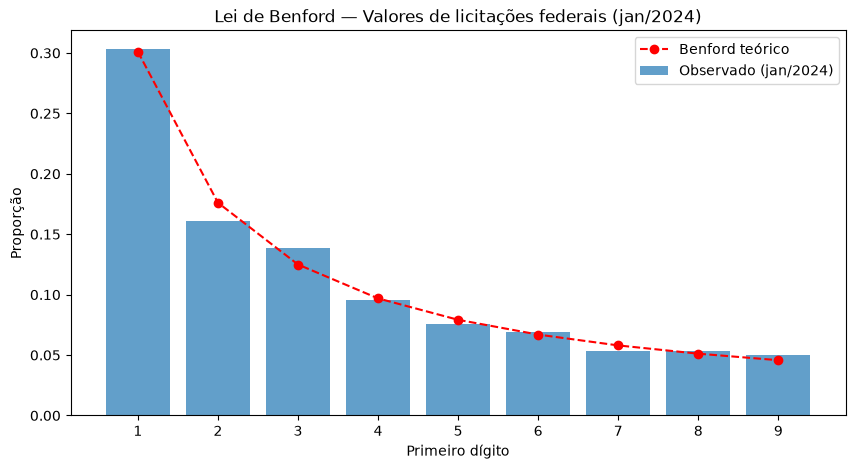

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tabela.index, tabela["observado"], alpha=0.7, label="Observado (jan/2024)")
ax.plot(tabela.index, tabela["esperado"], "ro--", label="Benford teórico")
ax.set_xticks(range(1, 10))
ax.set_xlabel("Primeiro dígito")
ax.set_ylabel("Proporção")
ax.set_title("Lei de Benford — Valores de licitações federais (jan/2024)")
ax.legend()
plt.savefig("../reports/benford_jan2024.png", dpi=150, bbox_inches="tight")
plt.show()

In [5]:
%pip install scipy


Note: you may need to restart the kernel to use updated packages.


In [6]:
from scipy.stats import chisquare

valores = df["Valor Licitação"]
n = (valores > 0).sum()  # total de valores validos

observado_abs = (tabela["observado"] * n).round()
esperado_abs = tabela["esperado"] * n

chi2, p_valor = chisquare(f_obs=observado_abs, f_exp=esperado_abs)
print(f"qui-quadrado = {chi2:.2f}")
print(f"p-valor = {p_valor:.4f}")

qui-quadrado = 6.42
p-valor = 0.6001
